# Implementación de un ARIMA paso a paso

Pronóstico del comportamiento del índice S&P

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

from statsforecast import StatsForecast
from statsforecast.models import Naive, ARIMA
import statsmodels.api as sm

sns.set_theme(style = 'darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [41]:
df = pd.read_csv('datos/S&P_500.csv',
                parse_dates=['ds'])
df

,unique_id,ds,y
0,S&P 500,2020-06-01,3055.729980
1,S&P 500,2020-06-02,3080.820068
2,S&P 500,2020-06-03,3122.870117
3,S&P 500,2020-06-04,3112.350098
4,S&P 500,2020-06-05,3193.929932
...,...,...,...
1400,S&P 500,2025-12-24,6932.049805
1401,S&P 500,2025-12-26,6929.939941
1402,S&P 500,2025-12-29,6905.740234
1403,S&P 500,2025-12-30,6896.240234


<Axes: xlabel='ds', ylabel='y'>

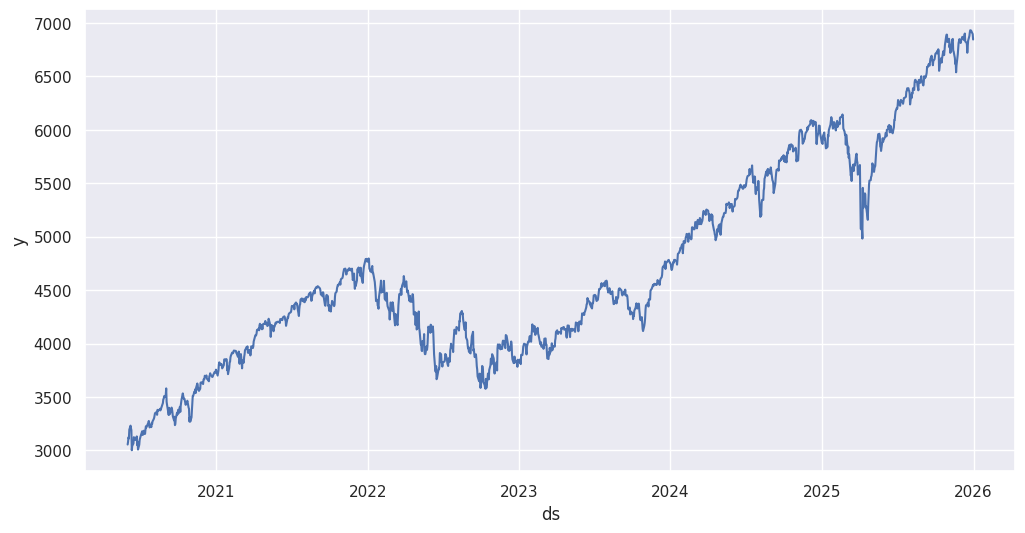

In [42]:
sns.lineplot(data = df, x = 'ds', y = 'y')

Evidentemente es una Serie no estacionaria.

Así que para este caso supondremos que el problema a resolver es **desarrollar un modelo predictivo para pronosticar el comportamiento del S&P 500 con un horizonte de 5 días**.


## Pasos involucrados en el desarrollo de un modelo predictivo (caso especial ARIMA)

1. Definir claramente el problema de predicción
2. Explorar y realizar limpieza de los datos
3. Entrenar y validar un simple modelo base (o de referencia)
4. Definir el tipo de modelo predictivo a implementar (teniendo en cuenta las características de la Serie)
5. Verificar si se cumplen los supuestos del modelo
6. Seleccionar el mejor conjunto de hiper-parámetros del modelo
7. Validar el modelo y comparar su desempeño con el del modelo base (3)
8. Generar pronósticos con el modelo seleccionado en el paso anterior


## Paso 3 Modelo base - Naive



En este caso (acciones en la bolsa) el método Näive es el método recomendado. En este método el siguiente valor pronosticado (o el pronóstico para una ventana "h") es simplemente la última observación:

$$y_{t+h} = y_t$$

Así que la idea es construir y evaluar el desempeño de este modelo con nuestra Serie de Tiempo y luego usar estas métricas como referencia para modelos más sofisticados.

<Axes: xlabel='ds', ylabel='y'>

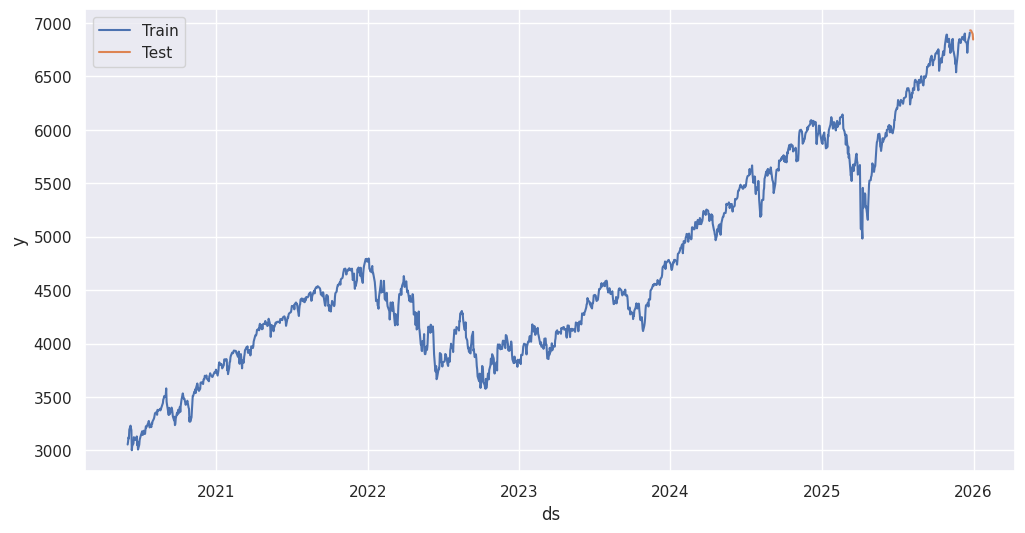

In [43]:
N = len(df)

df_train = df.iloc[ :N-5]
df_test = df.iloc[N-5: ]

sns.lineplot(data = df_train, x = 'ds', y = 'y', label = 'Train')
sns.lineplot(data = df_test, x = 'ds', y = 'y', label = 'Test')

<Axes: xlabel='ds', ylabel='y'>

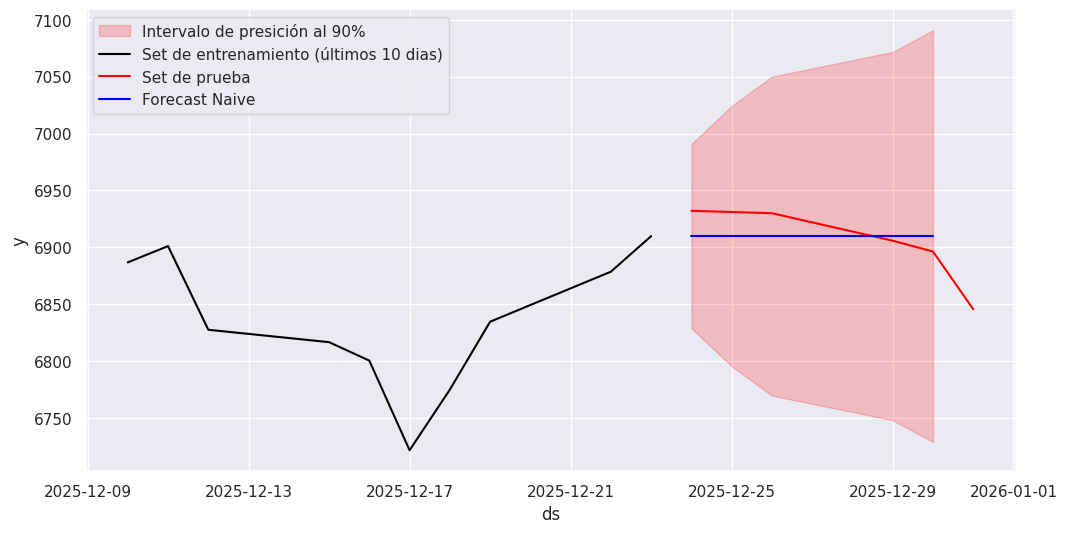

In [47]:
sf_naive = StatsForecast(models = [Naive(alias = 'Naive')], freq = 'B')
sf_naive.fit(df_train)

fc_naive = sf_naive.forecast(df = df_train, h = 5, level = [90])

fig, ax = plt.subplots()
plt.fill_between(
    x = fc_naive['ds'],
    y1 = fc_naive['Naive-lo-90'],
    y2 = fc_naive['Naive-hi-90'],
    color = 'red', 
    alpha = 0.2,
    label = 'Intervalo de presición al 90%')
sns.lineplot(df_train[-10: ], x = 'ds', y = 'y', label = 'Set de entrenamiento (últimos 10 dias)', color = 'black')
sns.lineplot(df_test, x = 'ds', y = 'y', label = 'Set de prueba', color = 'red')
sns.lineplot(fc_naive, x = 'ds', y = 'Naive', label = 'Forecast Naive', color = 'blue')


#### Medir el desempeño mediante ventanas expandibles
- Número de ventadas: 24
- Horizonte de predicción : 5
- Tamaño de paso : 10

In [52]:
cv_df_naive = sf_naive.cross_validation(
    df = df_train,
    h = 5,
    step_size = 10,
    n_windows = 24)
cv_df_naive.head(10)

,unique_id,ds,cutoff,y,Naive
0,S&P 500,2025-01-17,2025-01-16,5996.660156,5937.339844
1,S&P 500,2025-01-21,2025-01-16,6049.240234,5937.339844
2,S&P 500,2025-01-22,2025-01-16,6086.370117,5937.339844
3,S&P 500,2025-01-23,2025-01-16,6118.709961,5937.339844
4,S&P 500,2025-01-24,2025-01-16,6101.240234,5937.339844
5,S&P 500,2025-02-03,2025-01-31,5994.569824,6040.529785
6,S&P 500,2025-02-04,2025-01-31,6037.879883,6040.529785
7,S&P 500,2025-02-05,2025-01-31,6061.479980,6040.529785
8,S&P 500,2025-02-06,2025-01-31,6083.569824,6040.529785
9,S&P 500,2025-02-07,2025-01-31,6025.990234,6040.529785


In [98]:
def metricas_cv(cv_df, nombre_modelos):
    resultados = []
    for modelo in nombre_modelos:
        #Agrupar por cutoff y calcular métricas
        metricas_ventana = []
        for cutoff in cv_df['cutoff'].unique():
            ventana = cv_df[cv_df['cutoff'] == cutoff]
            y_true = ventana['y']
            y_pred = ventana[modelo]

            rmse = np.sqrt(np.mean(y_true - y_pred)**2)
            mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
            mae = np.mean(np.abs(y_true - y_pred))

            metricas_ventana.append({'rmse' : rmse, 'mape' : mape, 'mae' : mae})
        
        metricas_df = pd.DataFrame(metricas_ventana)
        resultados.append({
            'Modelo' : modelo,
            'RMSE' : metricas_df['rmse'].mean(),
            'MAPE' : metricas_df['mape'].mean(),
            'MAE' : metricas_df['mae'].mean(),
            'RMSE_STD' : metricas_df['rmse'].std(),
            'MAPE_STD' : metricas_df['mape'].std(),     
            'MAE_STD' : metricas_df['mae'].std()    
        })
    df_resultados = pd.DataFrame(resultados)
    df_resultados.index = df_resultados.index + 1
    return df_resultados

In [62]:
metricas_naive = metricas_cv(cv_df_naive, ['Naive'])
metricas_naive

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
0,Naive,58.84814,1.145956,68.173637,53.020342,1.044529,53.37143


El modelo Näive no lo hace nada mal:

- Su error RMSE medio es de 58.84 USD  +- 54-02 USD. Si asumimos una media en la Serie de 5.000 USD, este error +- desviación son del orden de 1.6% +- 1.4%
- Y esto coincide con el bajo MAPE obtenido: 1.14 +- 1.04 %

Esta es la referencia para comparar con un experimento de ARIMA

## Paso 4 Definir el modelo a Implementar

- ARIMA

## Paso 5 Supuestos del modelo

- La serie de tiempo no tiene un componente estacional
- La serie es no estacionaria (Se puede diferenciar con el componenete **I**)
- La serie tiene variaciónes aleatorias (Se pueden modelar con un componente **MA**)

## Paso 6 Seleccionar el mejor conjunto de hiperparámetros (p, d, q)

- **p**: mediante PACF
- **d**: mediante diferencición
- **q**: mediante ACF

In [68]:
def prueba_diferenciacion(serie, d, titulo):
    serie = serie.dropna()

    if d != 0:
        for _ in range(d):
            serie = serie.diff()

    resultado = adfuller(serie.dropna())
    pval = resultado[1]

    if pval < 0.05:
        print('Rechazar H0: Serie estacionaria')
        print(f'pval: {pval:.4f} < 0.05')
        print('Ya no es necesario diferenciar mas')
    else:
        print('Aceptar H0: Serie no estacionaria')
        print(f'pval: {pval:.4f} >= 0.05')
        print('Necesita ser diferenciada')
    
    fig, ax = plt.subplots(1, 1, figsize = (15, 5))
    plt.plot(range(1, len(serie)+1), serie)
    plt.hlines(serie.mean(), xmin = 1, xmax = len(serie)+1, color = 'red', label = 'Media', linestyle = '--')
    plt.title(f'{titulo}, d = {d}')
    plt.xlabel('Tiempo')
    plt.ylabel('Valor')
    plt.legend()
    plt.show()


Aceptar H0: Serie no estacionaria
pval: 0.9572 >= 0.05
Necesita ser diferenciada


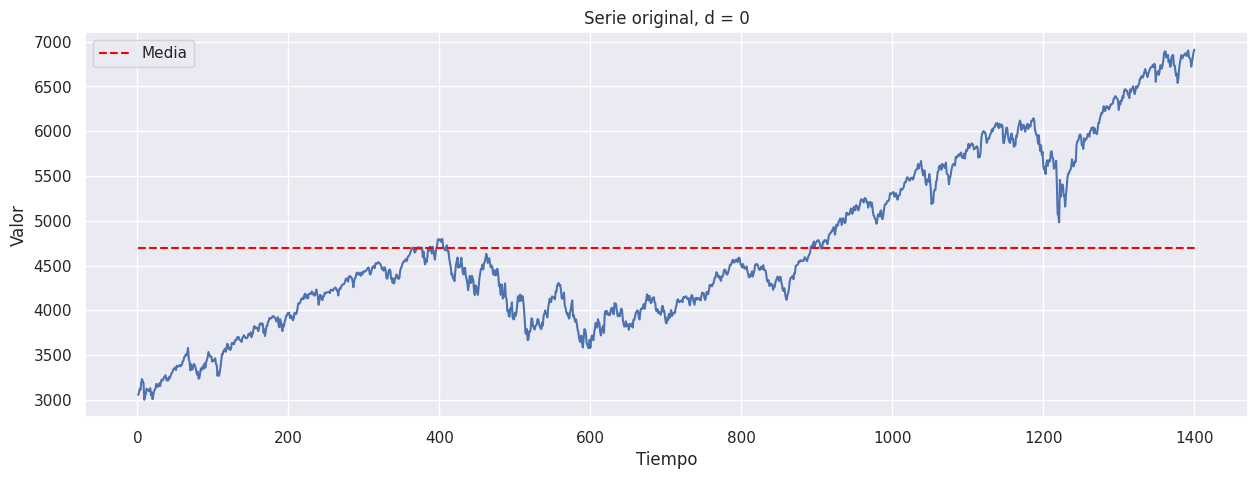

Rechazar H0: Serie estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar mas


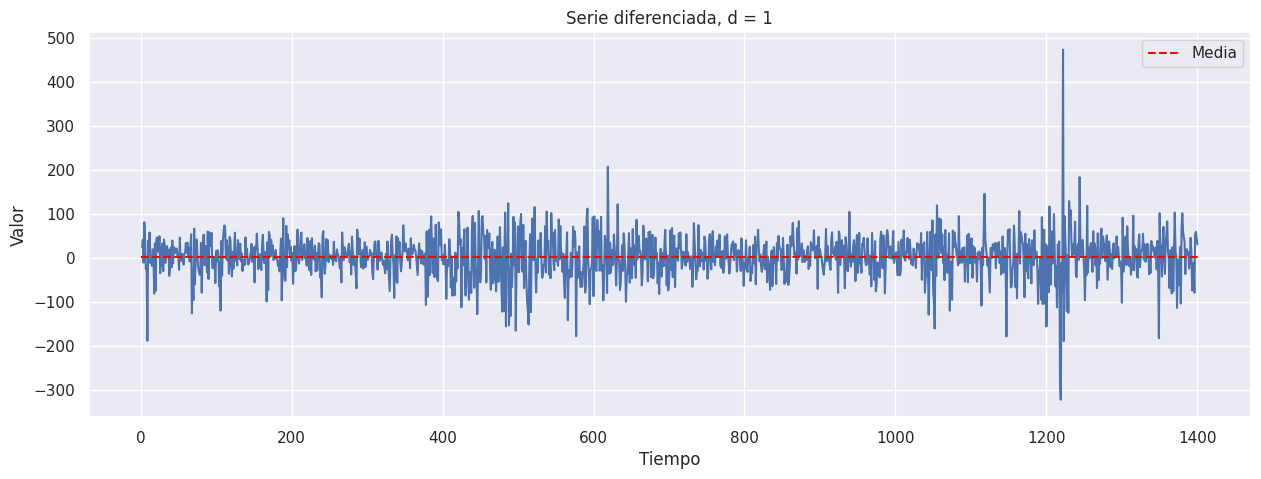

Rechazar H0: Serie estacionaria
pval: 0.0000 < 0.05
Ya no es necesario diferenciar mas


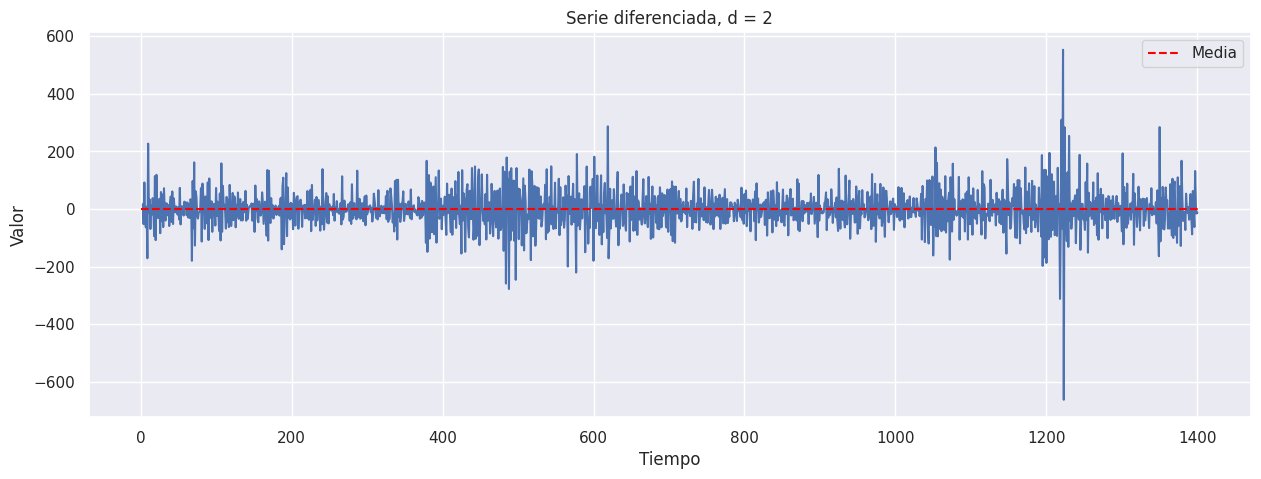

In [69]:
prueba_diferenciacion(df_train['y'], 0, 'Serie original')
prueba_diferenciacion(df_train['y'], 1, 'Serie diferenciada')
prueba_diferenciacion(df_train['y'], 2, 'Serie diferenciada')

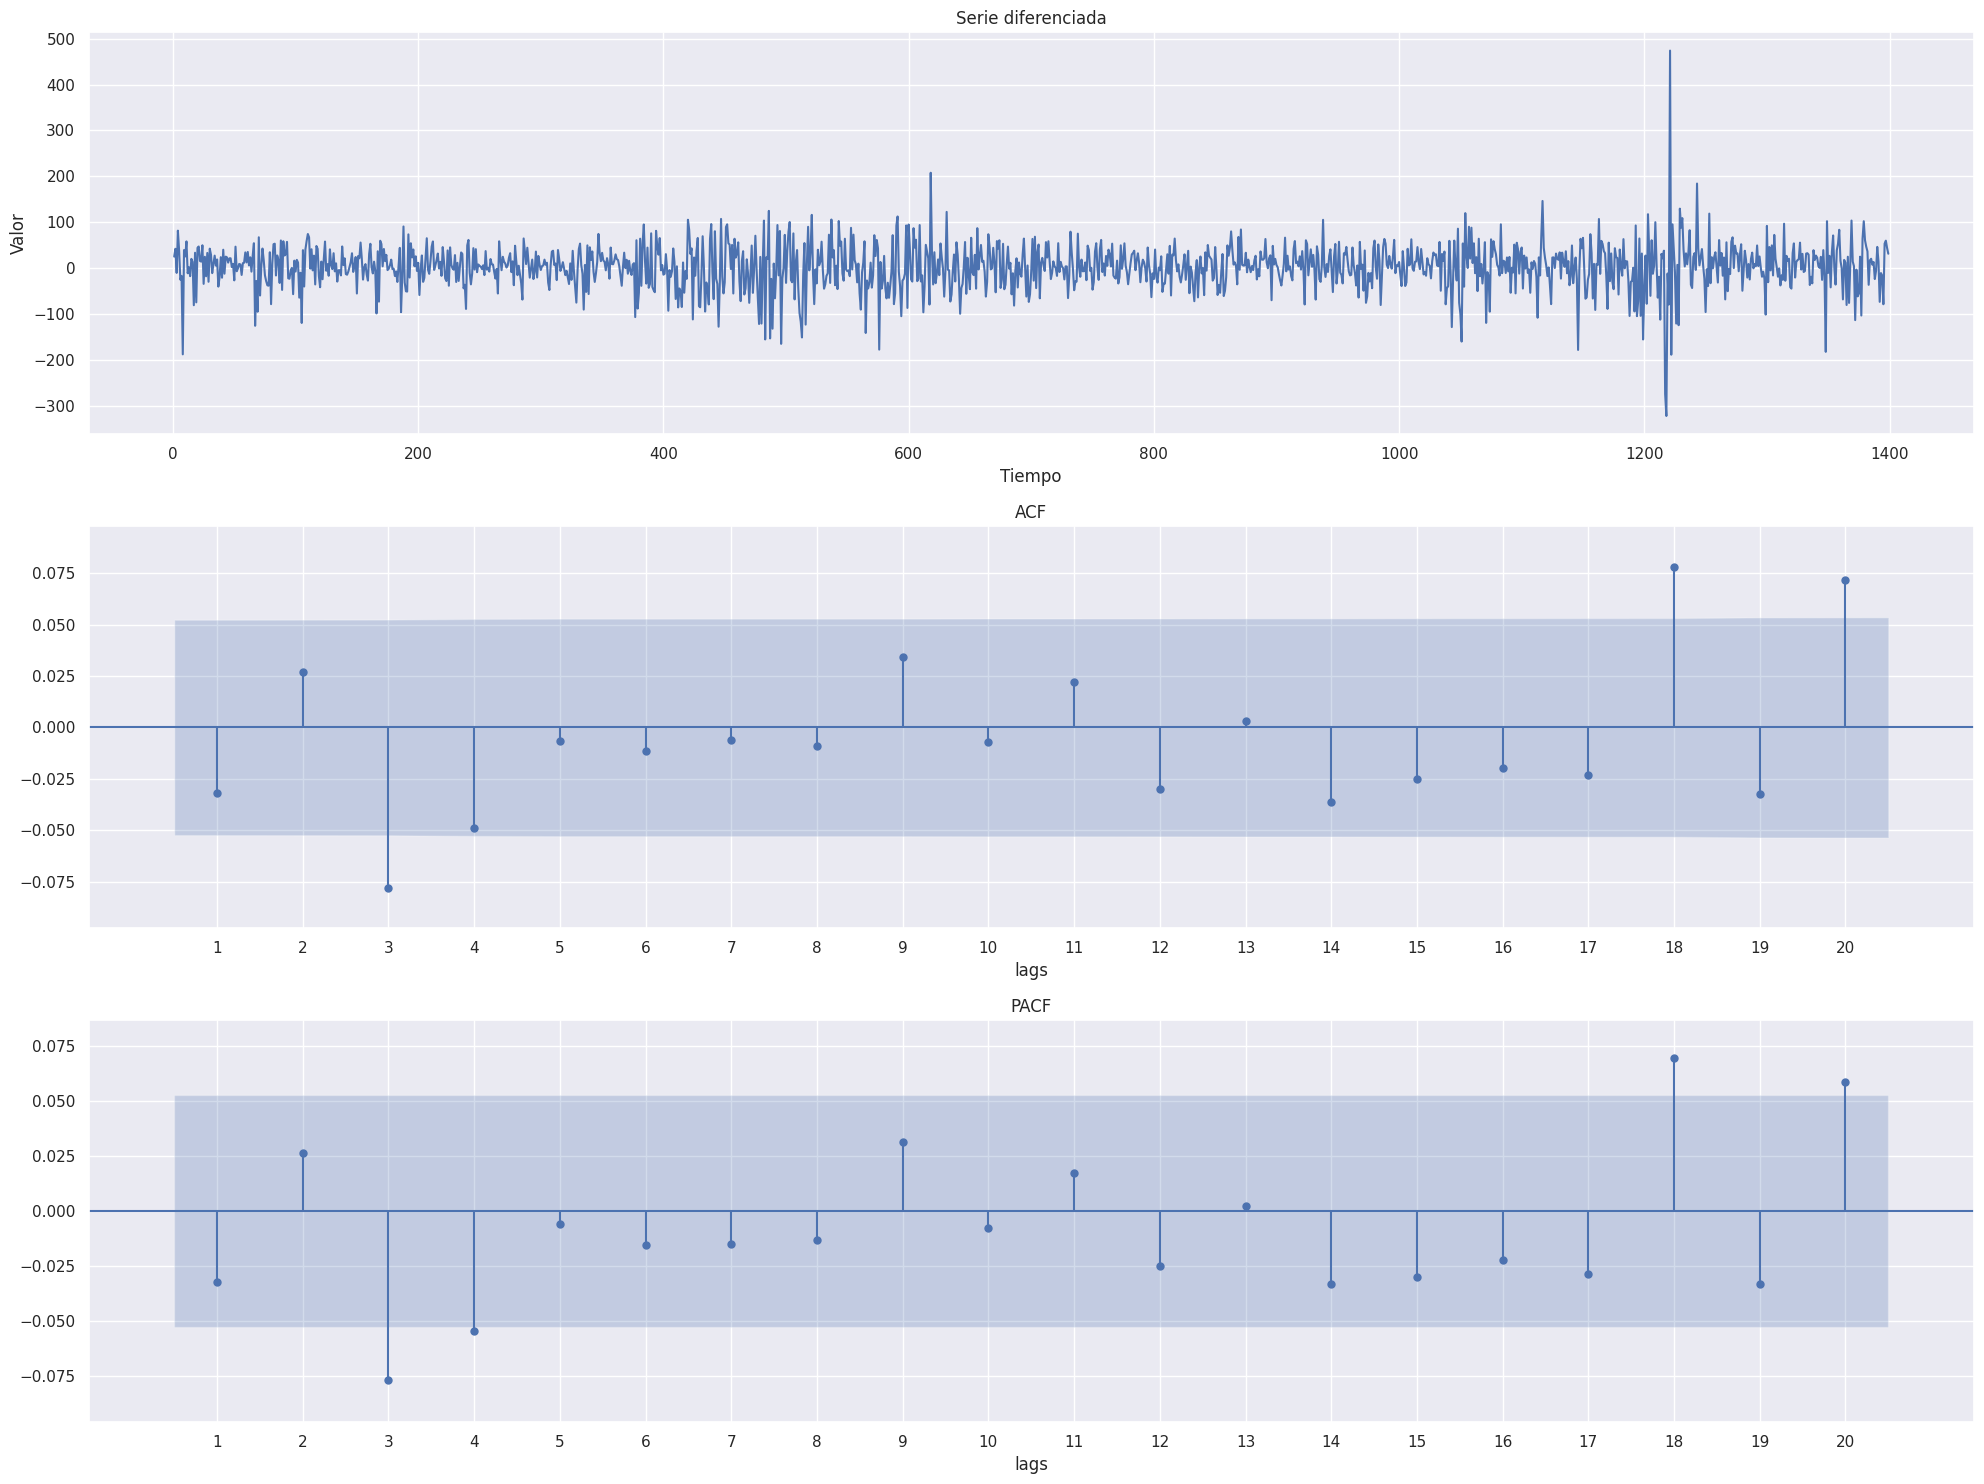

In [75]:
df_dif1 = df_train['y'].diff().dropna()

fig, ax = plt.subplots(3,1, figsize = (20, 15))

sns.lineplot(df_dif1, ax = ax[0])
ax[0].set_title('Serie diferenciada')
ax[0].set_xlabel('Tiempo')
ax[0].set_ylabel('Valor')

LAGS = 20
plot_acf(df_dif1,
        alpha = 0.05,
        lags = LAGS,
        zero = False,
        auto_ylims = True,
        ax = ax[1])
ax[1].set_title('ACF')
ax[1].set_xlabel('lags')
ax[1].set_xticks(range(1, LAGS+1))
ax[1].grid(True)

plot_pacf(df_dif1,
        alpha = 0.05,
        lags = LAGS,
        zero = False,
        auto_ylims = True,
        ax = ax[2])
ax[2].set_title('PACF')
ax[2].set_xlabel('lags')
ax[2].set_xticks(range(1, LAGS+1))
ax[2].grid(True)

plt.tight_layout()

**Observaciones:**
- En la ACF al parecer q=3 o q=4 podrían resultar adecuados 
- En la PACF al parecer p=3 o p=4 podrían resultar adecuados

En este caso, simplemente observando las gráficas, no podemos decidir claramente entre una opción y la otra. Así que la solución es hacer un **ajuste de hiper-parámetros del modelo ARIMA**:

1. Elegimos una **grilla de hiper-parámetros**
2. Por cada combinación de hiper-parámetros entrenamos y validamos los modelos correspondientes
3. Y elegimos, de ser posible, los parámetros con el mejor desempeño

Y acá es importante introducir un criterio importante (que aplica para modelos ARIMA pero en general para cualquier modelo predictivo):

> En caso de obtener desempeños similares se sugiere usar el modelo más simple (con menos hiper-parámetros) posible

Así que además de considerar modelos con los posibles valores de p y q encontrados anteriormente, consideraremos modelos aún más simples.

Estos serán los rangos de valores a considerar:

- $p = \{0, 1, 2, 3, 4\}$
- $d = 1$
- $q = \{0, 1, 2, 3, 4\}$

In [92]:
ps = range(0, 5)
qs = range(0, 5)
d = 1

modelos = [ARIMA(order = (p, d, q), alias = f'ARIMA({p}, {d}, {q})', include_constant = False) for p in ps for q in qs]
sf = StatsForecast(models = modelos, freq = 'B', n_jobs = -1)

print(f'Se crearon {len(modelos)} modelos')
modelos

Se crearon 25 modelos


[ARIMA(0, 1, 0),
 ARIMA(0, 1, 1),
 ARIMA(0, 1, 2),
 ARIMA(0, 1, 3),
 ARIMA(0, 1, 4),
 ARIMA(1, 1, 0),
 ARIMA(1, 1, 1),
 ARIMA(1, 1, 2),
 ARIMA(1, 1, 3),
 ARIMA(1, 1, 4),
 ARIMA(2, 1, 0),
 ARIMA(2, 1, 1),
 ARIMA(2, 1, 2),
 ARIMA(2, 1, 3),
 ARIMA(2, 1, 4),
 ARIMA(3, 1, 0),
 ARIMA(3, 1, 1),
 ARIMA(3, 1, 2),
 ARIMA(3, 1, 3),
 ARIMA(3, 1, 4),
 ARIMA(4, 1, 0),
 ARIMA(4, 1, 1),
 ARIMA(4, 1, 2),
 ARIMA(4, 1, 3),
 ARIMA(4, 1, 4)]

In [93]:
cv_df = sf.cross_validation(
    df = df_train,
    h = 5,
    step_size = 10,
    n_windows = 24)
cv_df.head(10)

,unique_id,ds,cutoff,y,"ARIMA(0, 1, 0)","ARIMA(0, 1, 1)","ARIMA(0, 1, 2)","ARIMA(0, 1, 3)","ARIMA(0, 1, 4)","ARIMA(1, 1, 0)",...,"ARIMA(3, 1, 0)","ARIMA(3, 1, 1)","ARIMA(3, 1, 2)","ARIMA(3, 1, 3)","ARIMA(3, 1, 4)","ARIMA(4, 1, 0)","ARIMA(4, 1, 1)","ARIMA(4, 1, 2)","ARIMA(4, 1, 3)","ARIMA(4, 1, 4)"
0,S&P 500,2025-01-17,2025-01-16,5996.660156,5937.339844,5937.313147,5935.983163,5935.482720,5935.411505,5937.314241,...,5935.707245,5936.426578,5936.975369,5942.037924,5938.210185,5935.350103,5935.873785,5934.667799,5934.550948,5939.721472
1,S&P 500,2025-01-21,2025-01-16,6049.240234,5937.339844,5937.313147,5936.141401,5930.191723,5930.138512,5937.314189,...,5930.429191,5931.286273,5932.149947,5937.889861,5933.978860,5929.877435,5930.410883,5930.432092,5931.226163,5938.871222
2,S&P 500,2025-01-22,2025-01-16,6086.370117,5937.339844,5937.313147,5936.141401,5930.840861,5929.148845,5937.314189,...,5931.079916,5929.495173,5931.534644,5937.881954,5932.231311,5928.562995,5928.432558,5925.939531,5926.992532,5939.670584
3,S&P 500,2025-01-23,2025-01-16,6118.709961,5937.339844,5937.313147,5936.141401,5930.840861,5929.375430,5937.314189,...,5931.226544,5928.774558,5930.210644,5940.203474,5935.184204,5928.973216,5928.165331,5925.897986,5926.052042,5939.586199
4,S&P 500,2025-01-24,2025-01-16,6101.240234,5937.339844,5937.313147,5936.141401,5930.840861,5929.375430,5937.314189,...,5931.486610,5928.698715,5929.980391,5935.197097,5929.459231,5929.310731,5928.398612,5929.465399,5928.684276,5937.459611
5,S&P 500,2025-02-03,2025-01-31,5994.569824,6040.529785,6040.491891,6040.262737,6041.833242,6040.838370,6040.492508,...,6041.685301,6041.328024,6041.801126,6048.012516,6047.447598,6040.708763,6040.988831,6042.079936,6042.370400,6046.982866
6,S&P 500,2025-02-04,2025-01-31,6037.879883,6040.529785,6040.491891,6040.504881,6040.664827,6040.191116,6040.492462,...,6040.331882,6040.521547,6040.372480,6039.168926,6038.972092,6039.871400,6040.134096,6041.372118,6041.732451,6046.972169
7,S&P 500,2025-02-05,2025-01-31,6061.479980,6040.529785,6040.491891,6040.504881,6042.125743,6041.256459,6040.492462,...,6041.842745,6041.503316,6041.813031,6048.017375,6047.399168,6040.862455,6041.065710,6039.018110,6038.939744,6045.417418
8,S&P 500,2025-02-06,2025-01-31,6083.569824,6040.529785,6040.491891,6040.504881,6042.125743,6041.730975,6040.492462,...,6041.796283,6041.965756,6041.739313,6041.623659,6042.360171,6041.393352,6041.608119,6038.287659,6038.138087,6047.275472
9,S&P 500,2025-02-07,2025-01-31,6025.990234,6040.529785,6040.491891,6040.504881,6042.125743,6041.730975,6040.492462,...,6041.852231,6042.226601,6042.179432,6044.493604,6043.844169,6041.423580,6041.787744,6039.487675,6039.846622,6041.573712


In [99]:
alias_modelos = [m.alias for m in modelos]
metricas_modelos = metricas_cv(cv_df, alias_modelos)
metricas_modelos

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
1,"ARIMA(0, 1, 0)",58.848140,1.145956,68.173637,53.020342,1.044529,53.371430
2,"ARIMA(0, 1, 1)",59.175606,1.148168,68.323146,52.730026,1.042668,53.281571
3,"ARIMA(0, 1, 2)",58.815073,1.144081,68.072966,53.106172,1.047599,53.585236
4,"ARIMA(0, 1, 3)",61.400511,1.185037,70.526548,54.331714,1.056862,54.093940
5,"ARIMA(0, 1, 4)",61.847059,1.191821,71.012452,54.782260,1.052697,53.953007
6,"ARIMA(1, 1, 0)",59.183480,1.148216,68.326233,52.727685,1.042740,53.285580
7,"ARIMA(1, 1, 1)",59.683986,1.156863,68.807297,53.885488,1.057293,54.071549
8,"ARIMA(1, 1, 2)",59.465903,1.155702,68.728209,54.650030,1.066130,54.592316
9,"ARIMA(1, 1, 3)",61.982735,1.199570,71.429241,54.986716,1.056834,54.105917
10,"ARIMA(1, 1, 4)",61.705447,1.198998,71.404550,54.880099,1.057071,54.132217


In [ ]:
metricas_modelos.sort_values('RMSE', ascending = True)
# Los errores y las desviaciónes son muy cercanas

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
3,"ARIMA(0, 1, 2)",58.815073,1.144081,68.072966,53.106172,1.047599,53.585236
1,"ARIMA(0, 1, 0)",58.848140,1.145956,68.173637,53.020342,1.044529,53.371430
11,"ARIMA(2, 1, 0)",58.876866,1.144701,68.109669,53.089318,1.047873,53.600153
12,"ARIMA(2, 1, 1)",59.051963,1.150955,68.474719,53.738020,1.055485,54.068566
2,"ARIMA(0, 1, 1)",59.175606,1.148168,68.323146,52.730026,1.042668,53.281571
6,"ARIMA(1, 1, 0)",59.183480,1.148216,68.326233,52.727685,1.042740,53.285580
8,"ARIMA(1, 1, 2)",59.465903,1.155702,68.728209,54.650030,1.066130,54.592316
7,"ARIMA(1, 1, 1)",59.683986,1.156863,68.807297,53.885488,1.057293,54.071549
13,"ARIMA(2, 1, 2)",60.361130,1.161944,69.140701,53.632114,1.052835,53.834472
16,"ARIMA(3, 1, 0)",61.209892,1.182114,70.344102,54.343538,1.057803,54.145989


In [ ]:
metricas_modelos.sort_values('MAPE', ascending = True)
# Nos podeos quedar con los primeros 3

,Modelo,RMSE,MAPE,MAE,RMSE_STD,MAPE_STD,MAE_STD
3,"ARIMA(0, 1, 2)",58.815073,1.144081,68.072966,53.106172,1.047599,53.585236
11,"ARIMA(2, 1, 0)",58.876866,1.144701,68.109669,53.089318,1.047873,53.600153
1,"ARIMA(0, 1, 0)",58.848140,1.145956,68.173637,53.020342,1.044529,53.371430
2,"ARIMA(0, 1, 1)",59.175606,1.148168,68.323146,52.730026,1.042668,53.281571
6,"ARIMA(1, 1, 0)",59.183480,1.148216,68.326233,52.727685,1.042740,53.285580
12,"ARIMA(2, 1, 1)",59.051963,1.150955,68.474719,53.738020,1.055485,54.068566
8,"ARIMA(1, 1, 2)",59.465903,1.155702,68.728209,54.650030,1.066130,54.592316
7,"ARIMA(1, 1, 1)",59.683986,1.156863,68.807297,53.885488,1.057293,54.071549
13,"ARIMA(2, 1, 2)",60.361130,1.161944,69.140701,53.632114,1.052835,53.834472
16,"ARIMA(3, 1, 0)",61.209892,1.182114,70.344102,54.343538,1.057803,54.145989


In [ ]:
def analizar_residuales(orden, data_train):
    p, d, q = orden
    modelo = [ARIMA(order = (p, d, q), alias = f'ARIMA({p}, {d}, {q})', include_constant = False)]
    sf = StatsForecast(models = modelo, freq = 'B')

    sf.fit(data_train)
    modelo_sf = sf.fitted_[0][0].model_
    res = modelo_sf['residuals']

    fig, axs = plt.subplots(4,1,figsize=(12,12))
    sns.lineplot(df_train["y"], ax=axs[0])
    axs[0].set_title('Serie de tiempo original')

    sns.lineplot(res, ax=axs[1])
    axs[1].set_title('Residuales en el tiempo')

    sns.histplot(res, ax=axs[2])
    axs[2].set_title('Histograma de los residuales')

    plot_acf(res, ax=axs[3])
    axs[3].set_title('ACF de los residuales')
    axs[3].set_ylim([-0.5, 1.5])

    plt.tight_layout()

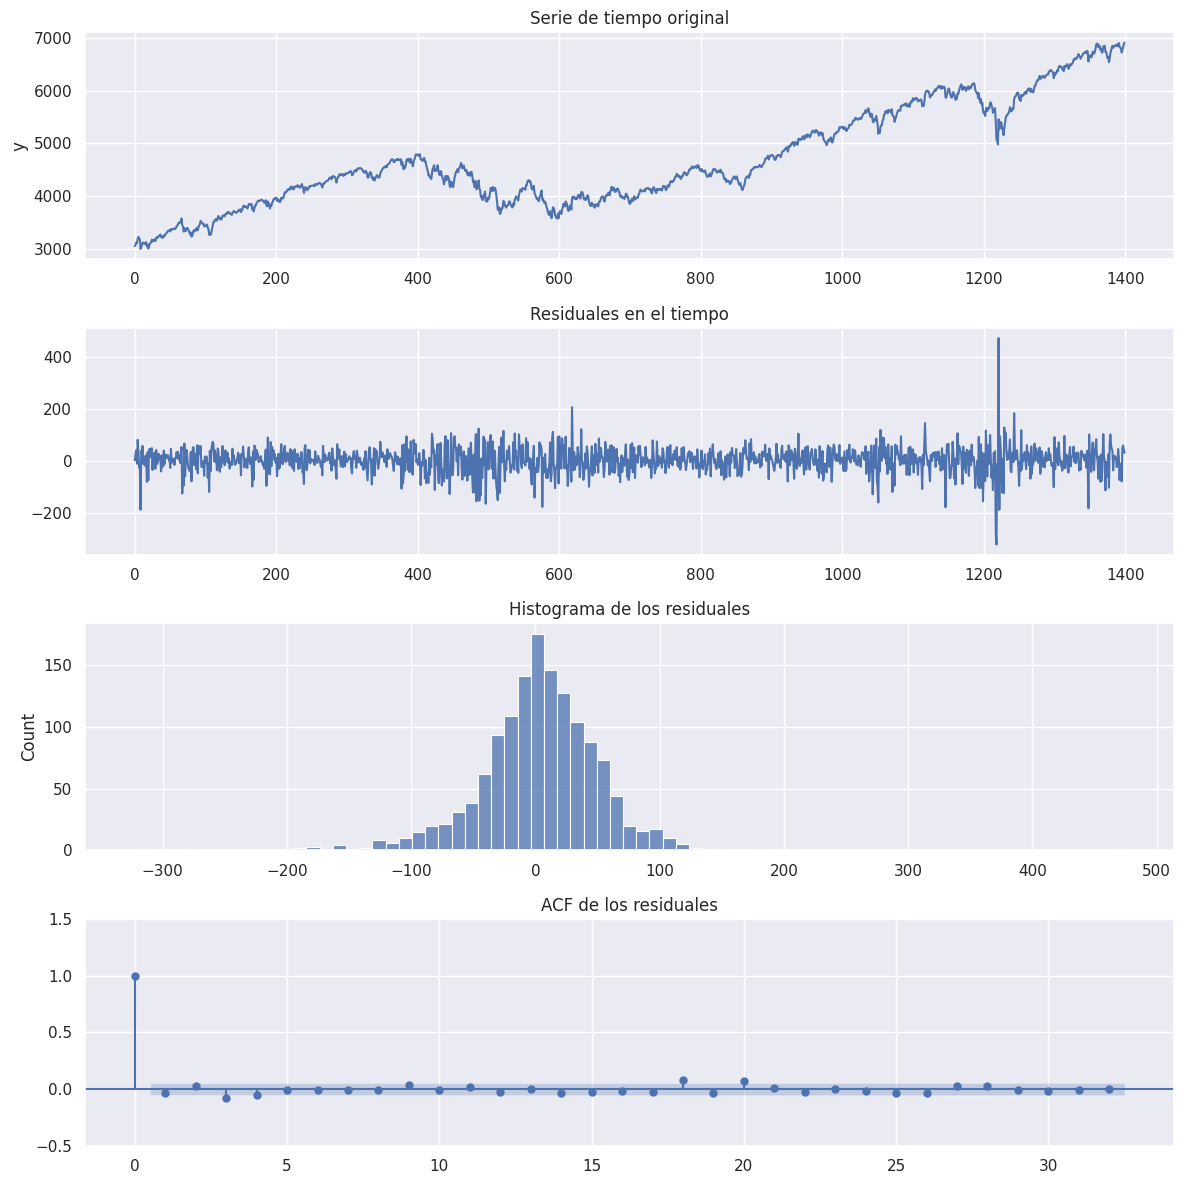

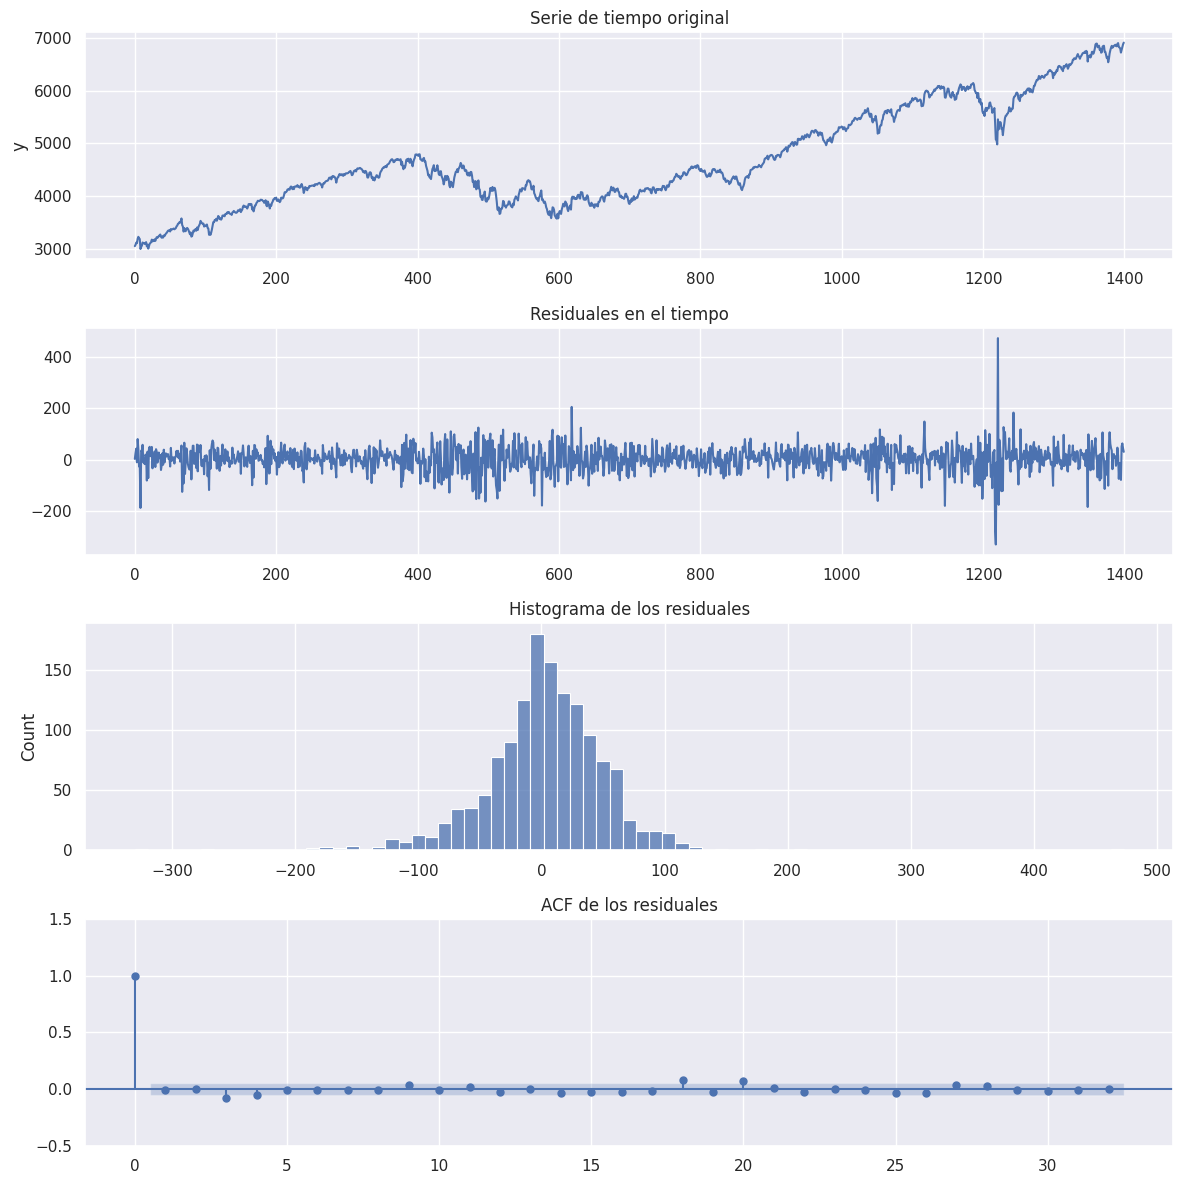

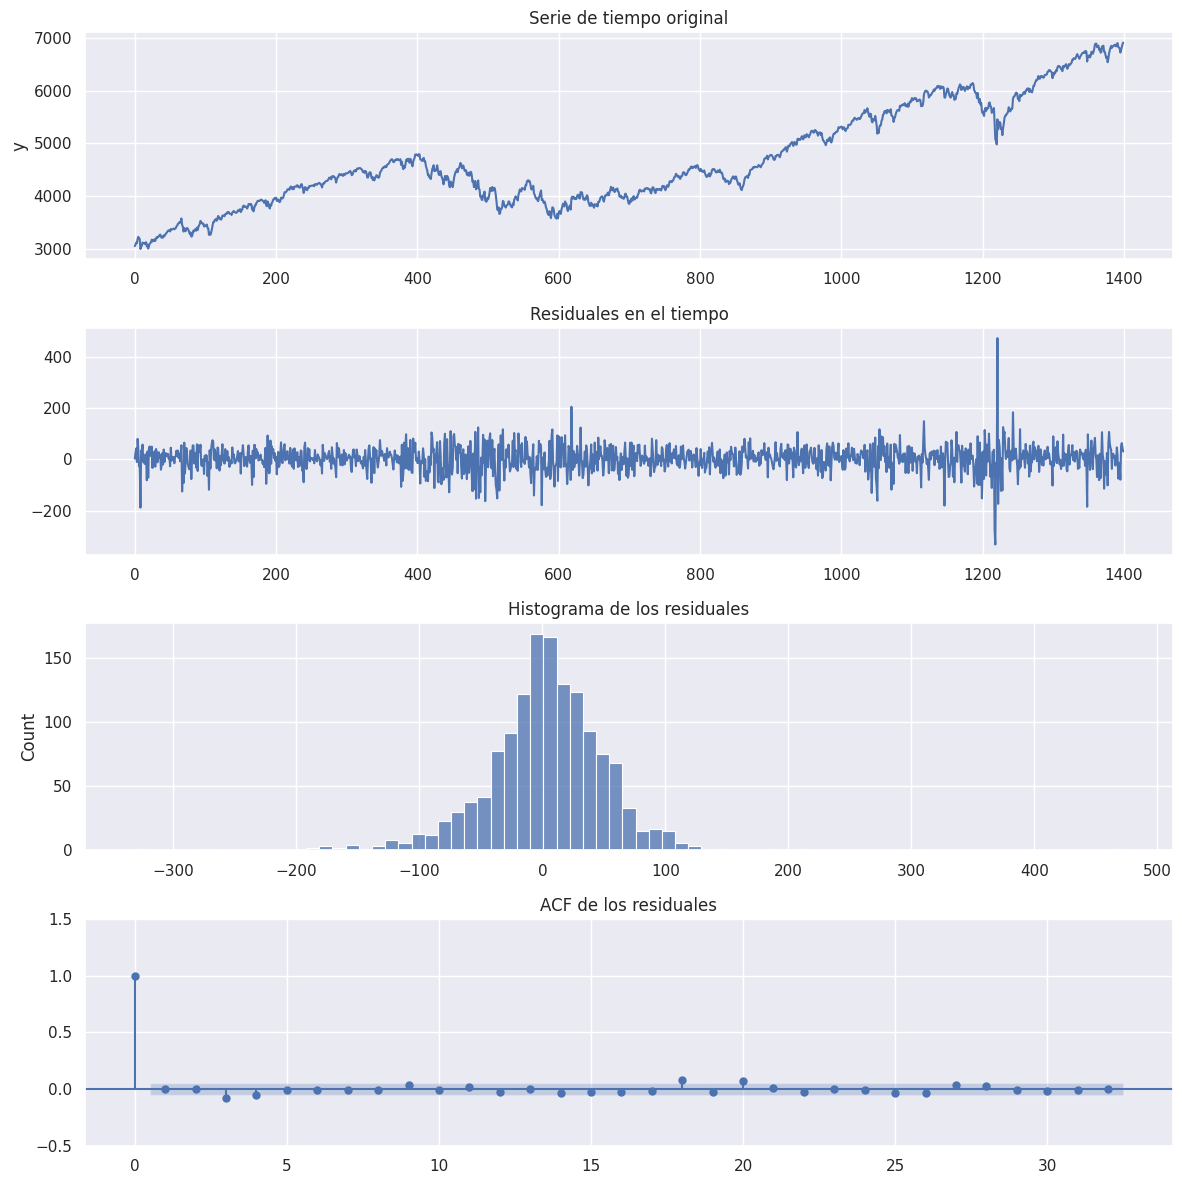

In [108]:
analizar_residuales(orden = (0, 1, 0), data_train = df_train)
analizar_residuales(orden = (0, 1, 2), data_train = df_train)
analizar_residuales(orden = (2, 1, 0), data_train = df_train)

##### Aplicación de la prueba de Wald

* H0: (p > 0.05) El parámetro es practicamente irrelevante
* H1: (p < 0.05) El parámetro es diferente de 0

A pesar de que se tienen parametros, estadísticamente pueden ser iguales a 0. Por lo que la comparación con los modelos:
* (0, 1, 0)
* (2, 1, 0)
* (0, 1, 2)

**Son estadísticamente equivalentes**

In [112]:
modelo_sm = sm.tsa.ARIMA(df_train['y'], order = (0, 1, 2), trend = 'n')
resultados = modelo_sm.fit()
print('Valores p del modelo (0, 1, 2)')
print(resultados.pvalues)

modelo_sm = sm.tsa.ARIMA(df_train['y'], order = (2, 1, 0), trend = 'n')
resultados = modelo_sm.fit()
print('\nValores p del modelo (0, 1, 2)')
print(resultados.pvalues)

modelo_sm = sm.tsa.ARIMA(df_train['y'], order = (0, 1, 0), trend = 'n')
resultados = modelo_sm.fit()
print('\nValores p del modelo (0, 1, 2)')
print(resultados.pvalues)

Valores p del modelo (0, 1, 2)
ma.L1     0.134097
ma.L2     0.218473
sigma2    0.000000
dtype: float64

Valores p del modelo (0, 1, 2)
ar.L1     0.075707
ar.L2     0.219077
sigma2    0.000000
dtype: float64

Valores p del modelo (0, 1, 2)
sigma2    0.0
dtype: float64
